# Business Size Classification — Nyeri County SBP Data
### Decision Tree and Random Forest Algorithms

**Author:** James Ndung'u Gitahi (S084-01-1968/2023)

This notebook follows the standard ML project workflow:

1. Import Required Libraries
2. Load the Dataset
3. Exploratory Data Analysis (EDA) on Raw Data
4. Data Cleaning & Preprocessing
5. Exploratory Data Analysis (EDA) on Cleaned Data
6. Feature Selection
7. Split the Dataset into Training and Testing Sets
8. Choose the Model
9. Train the Machine Learning Model
10. Make Predictions
11. Evaluate Model Performance

## 1. Import Required Libraries

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

sns.set_style("whitegrid")
RANDOM_STATE = 42

## 2. Load the Dataset

We start with the **raw, unedited file** exactly as received from Nyeri County Government,
so that every cleaning decision made later can be shown and justified rather than
applied silently.

In [9]:
raw_path = "County_SBP_Classified_Employees_Sqft.xlsx"  # original county file
df_raw = pd.read_excel(raw_path)
df_raw.shape

(18415, 22)

## 3. Exploratory Data Analysis (EDA) on Raw Data

Before touching the data, we inspect its structure, missingness, and target variable
to understand what cleaning is actually necessary — and why.

### 3.1 Structure and data types

In [10]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 18415 entries, 0 to 18414
Data columns (total 22 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Business ID                    18414 non-null  str    
 1   Permit No.                     18414 non-null  str    
 2   Business Name                  18414 non-null  str    
 3   PIN_No (KRA )                  1970 non-null   str    
 4   Activity / Category Code       18414 non-null  float64
 5   Activity Description           18414 non-null  str    
 6   Business Description           18414 non-null  str    
 7   county                         18414 non-null  float64
 8   Sub County                     18414 non-null  str    
 9   City/Town                      8234 non-null   str    
 10  Ward                           18414 non-null  str    
 11  Zone                           18413 non-null  str    
 12  Plot number                    18346 non-null  str    
 1

### 3.2 Missing values per column

This tells us which columns are usable and which are effectively empty.

In [11]:
missing_pct = (df_raw.isna().mean() * 100).sort_values(ascending=False)
missing_pct[missing_pct > 0]

Designation of contact person    100.000000
Website                          100.000000
Email                             94.591366
PIN_No (KRA )                     89.302199
City/Town                         55.286451
Postal Address                    51.555797
Plot number                        0.374695
Contact Details                    0.021721
Physical Address                   0.010861
Zone                               0.010861
Business ID                        0.005430
Activity / Category Code           0.005430
Business Name                      0.005430
Permit No.                         0.005430
Activity Description               0.005430
Business Description               0.005430
county                             0.005430
Sub County                         0.005430
Ward                               0.005430
Owner / Contact Person             0.005430
Permit Fee                         0.005430
Business Size                      0.005430
dtype: float64

**Observation:** Several columns are missing in the vast majority of records —
`Website` (100%), `Designation of contact person` (100%), `Email` (~94.6%),
`PIN_No (KRA)` (~89.3%), `Postal Address` (~51.6%), and `City/Town` (~55.3%).
These columns carry little to no analytical value for a business size classification
task and will be dropped in the cleaning step below.

### 3.3 Duplicate records

In [12]:
duplicate_count = df_raw['Business ID'].duplicated().sum()
print(f"Duplicate Business IDs: {duplicate_count}")

Duplicate Business IDs: 173


**Observation:** There are 173 duplicate `Business ID` entries. Since each business
should appear once in a licensing register, these duplicates need to be removed to avoid
double-counting the same business during model training.

### 3.4 Missing target values

In [13]:
missing_target = df_raw['Business Size'].isna().sum()
print(f"Rows with missing Business Size (target): {missing_target}")

Rows with missing Business Size (target): 1


**Observation:** 1 row has no `Business Size` label at all. Since this is our target
variable, a row without it cannot be used for supervised learning and must be dropped.

### 3.5 Target class distribution (raw)

In [14]:
df_raw['Business Size'].value_counts()

Business Size
Small     14361
Micro      3285
Medium      577
Large       191
Name: count, dtype: int64

**Observation:** The classes are heavily imbalanced — Small dominates, while Large
is a small minority. This will need to be accounted for later (via `class_weight='balanced'`
and macro F1-score rather than raw accuracy alone).

### 3.6 Label leakage check — Activity/Category Code vs Business Size

Before deciding which columns to use as model features, we check whether any column
already determines the target almost by itself, which would make the classification
task trivial rather than a genuine prediction problem.

In [15]:
leak_check = df_raw.groupby('Activity / Category Code')['Business Size'].nunique()
print(f"Category codes mapping to exactly one Business Size: {(leak_check == 1).sum()} out of {len(leak_check)}")

Category codes mapping to exactly one Business Size: 130 out of 138


**Observation:** 130 of 138 activity category codes map to exactly **one**
Business Size class. This means Business Size is almost entirely determined by the
category code — a form of **label leakage**. If `Activity/Category Code` were used as
a model feature, the model would essentially "look up" the answer rather than learn a
genuine relationship. For this reason, `Activity/Category Code` and `Activity Description`
are excluded from the feature set used later in this notebook.

## 4. Data Cleaning & Preprocessing

Based on the EDA findings above, we now clean the dataset step by step, explaining the
reason for each action.

### 4.1 Drop the row with a missing target

A record with no `Business Size` label cannot be used to train or evaluate a
classifier, so it is removed.

In [16]:
df = df_raw[df_raw['Business Size'].notna()].copy()
print(f"Rows after dropping missing target: {len(df)}")

Rows after dropping missing target: 18414


### 4.2 Remove duplicate Business IDs

Each business should be represented once. We keep the first occurrence of each
`Business ID` and drop the rest.

In [17]:
before = len(df)
df = df.drop_duplicates(subset=['Business ID'], keep='first')
print(f"Dropped {before - len(df)} duplicate rows. Remaining: {len(df)}")

Dropped 173 duplicate rows. Remaining: 18241


### 4.3 Drop columns with high missingness or no analytical value

Columns such as `Website`, `Email`, `PIN_No (KRA)`, contact details, and postal
address are either almost entirely empty or contain personal identifying information
that does not help classify business size. `county` is also dropped since every
record belongs to the same county (Nyeri) and therefore carries no information.

In [18]:
drop_cols = [
    'PIN_No (KRA )', 'Designation of contact person', 'Email', 'Website',
    'Postal Address', 'City/Town', 'Owner / Contact Person', 'Contact Details',
    'Business Name', 'Physical Address', 'Plot number', 'county'
]
df = df.drop(columns=[c for c in drop_cols if c in df.columns])
df.columns.tolist()

['Business ID',
 'Permit No.',
 'Activity / Category Code',
 'Activity Description',
 'Business Description',
 'Sub County',
 'Ward',
 'Zone',
 'Permit Fee',
 'Business Size']

### 4.4 Extract employee count and floor area (sqft) from free text

Although there is no dedicated numeric column for employee count or premises size,
some `Activity Description` entries mention these details in free text
(e.g. *"...premises less than 50 square feet"*). We extract these using regular
expressions. These extracted values are **not** used as model features later
(due to high missingness, discussed below) but are kept for descriptive analysis
and to demonstrate the conceptual link between business size and physical scale
referenced in the project title.

In [19]:
def extract_employees(text):
    if pd.isna(text):
        return np.nan
    text = str(text).lower()
    m = re.search(r'up ?to (\d+)\s*(employees|tellers|customers|workers)', text)
    if m:
        return int(m.group(1))
    m = re.search(r'(\d+)\s*(employees|workers)', text)
    if m:
        return int(m.group(1))
    if 'one person' in text or 'sole' in text:
        return 1
    return np.nan

def extract_sqft(text):
    if pd.isna(text):
        return np.nan, np.nan
    text = str(text).lower()
    m = re.search(r'(\d+)\s*(?:to|-)\s*(\d+)\s*square', text)
    if m:
        return int(m.group(1)), int(m.group(2))
    m = re.search(r'less than (\d+)\s*square', text)
    if m:
        return 0, int(m.group(1))
    m = re.search(r'(?:over|more than|above)\s*(\d+)\s*square', text)
    if m:
        return int(m.group(1)), np.nan
    m = re.search(r'(\d+)\s*square', text)
    if m:
        return np.nan, int(m.group(1))
    return np.nan, np.nan

df['Employees_extracted'] = df['Activity Description'].apply(extract_employees)
sqft = df['Activity Description'].apply(extract_sqft)
df['Sqft_min'] = sqft.apply(lambda x: x[0])
df['Sqft_max'] = sqft.apply(lambda x: x[1])
df['Sqft_mid'] = df[['Sqft_min', 'Sqft_max']].mean(axis=1)

print("Employees recovered:", df['Employees_extracted'].notna().sum())
print("Sqft recovered:", (df['Sqft_min'].notna() | df['Sqft_max'].notna()).sum())

Employees recovered: 1624
Sqft recovered: 4612


**Observation:** Employee count was recovered for only about 9% of records, and
square footage for about 25%. This confirms that these variables are too sparse to
serve as reliable model inputs across the full dataset, which is why the modeling
feature set (Section 6) relies on `Sub County`, `Ward`, `Zone`, and `Permit Fee`
instead — all of which are fully or near-fully observed.

### 4.5 Save the cleaned dataset

The cleaned dataframe is now ready for exploratory analysis and modeling.

In [21]:
df.to_excel("Nyeri_SBP_cleaned.xlsx", index=False)
print(f"Final cleaned shape: {df.shape}")
df.head()

Final cleaned shape: (18241, 14)


,Business ID,Permit No.,Activity / Category Code,Activity Description,Business Description,Sub County,Ward,Zone,Permit Fee,Business Size,Employees_extracted,Sqft_min,Sqft_max,Sqft_mid
1,A19H01214,2024/A19H0121401,220.0,Semi permanent informal sector trader up to 2 ...,Semi permanent informal sector trader up to 2 ...,MAT-Mathira East - Karatina Urban,Karatina Ward,Mathira - URBAN,1800.0,Micro,NaN,NaN,NaN,NaN
2,A19H01229,2024/A19H0122901,415.0,POSHO MILL,"Small agricultural producer, processor, dealer...",MUK-Mukurweini,Mukurwe-ini Central,Mukurweini - Rural,3000.0,Small,NaN,NaN,NaN,NaN
3,A19H01232,2024/A19H0123201,118.0,RETAIL SHOP,"Small trader, shop or retail services and/or p...",KW-Kieni West,Mugunda Ward,Kieni West - Rural,2000.0,Small,NaN,NaN,NaN,NaN
4,A19H01247,2024/A19H0124701,118.0,SELLING SPARE PARTS,"Small trader, shop or retail services and/or p...",NT-Nyeri Town,Rware Ward,Nyeri Town - URBAN,3000.0,Small,NaN,NaN,NaN,NaN
5,A19H01264,2024/A19H0126401,930.0,"Small workshop/service-repair, contractor, up ...","Small workshop/service-repair, contractor, up ...",MAT-Mathira East - Karatina Urban,Karatina Ward,Mathira - URBAN,4200.0,Micro,5.0,NaN,NaN,NaN


## 5. Exploratory Data Analysis (EDA) on Cleaned Data

With the data cleaned, we now visualize the key relationships that inform feature
selection and modeling choices.

### 5.1 Target class distribution

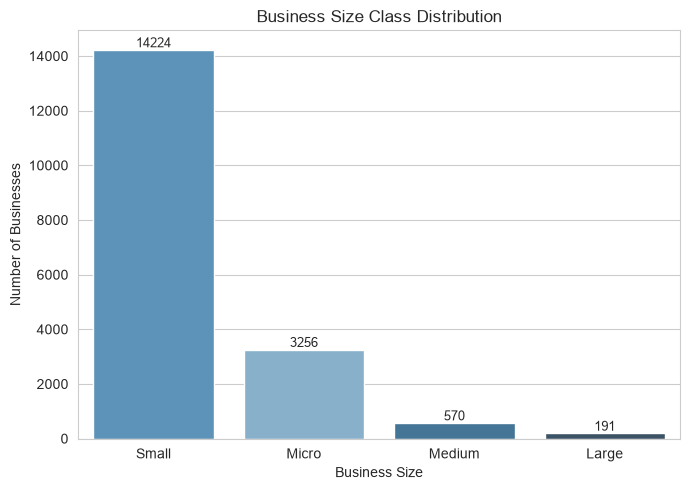

In [22]:
fig, ax = plt.subplots(figsize=(7, 5))
order = df['Business Size'].value_counts().index
sns.countplot(data=df, x='Business Size', order=order, hue='Business Size', palette='Blues_d', legend=False, ax=ax)
ax.set_title("Business Size Class Distribution")
ax.set_ylabel("Number of Businesses")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

### 5.2 Permit Fee by Business Size

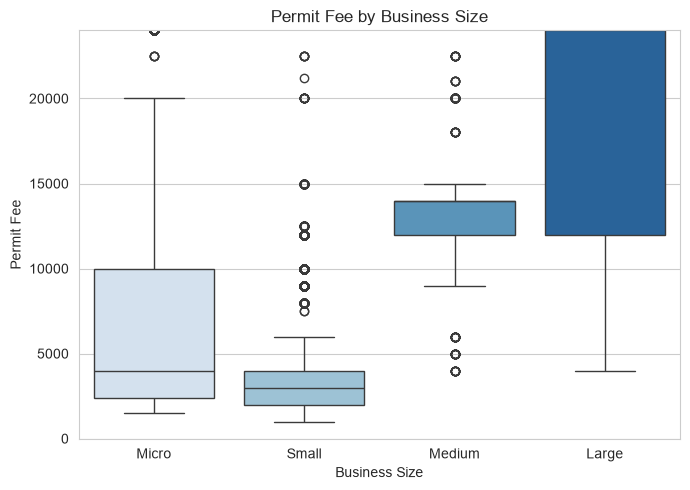

In [23]:
order = ['Micro', 'Small', 'Medium', 'Large']
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df, x='Business Size', y='Permit Fee', order=order, hue='Business Size', palette='Blues', legend=False, ax=ax)
ax.set_title("Permit Fee by Business Size")
ax.set_ylim(0, df['Permit Fee'].quantile(0.98))
plt.tight_layout()
plt.show()

**Observation:** Median Permit Fee increases steadily from Micro to Large, though
ranges overlap — Permit Fee carries real signal but is not a perfect predictor on its own.

### 5.3 Geographic distribution

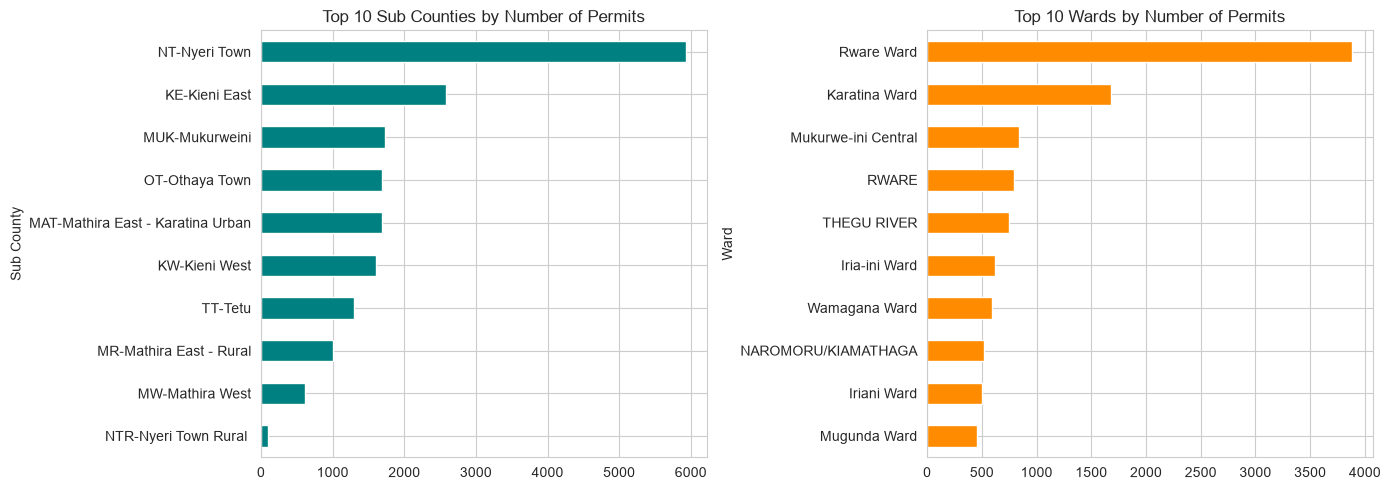

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df['Sub County'].value_counts().head(10).plot(kind='barh', ax=axes[0], color='teal')
axes[0].set_title("Top 10 Sub Counties by Number of Permits")
axes[0].invert_yaxis()

df['Ward'].value_counts().head(10).plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title("Top 10 Wards by Number of Permits")
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

## 6. Feature Selection

Based on the EDA and label-leakage check above, the model will use:

- `Sub County`, `Ward`, `Zone` — location attributes (encoded numerically)
- `Permit Fee` — licensing attribute

`Activity/Category Code` and `Activity Description` are **excluded** due to the
leakage identified in Section 3.6. `Employees_extracted` and `Sqft_*` are excluded
due to high missingness identified in Section 4.4.

In [25]:
features = ['Sub County', 'Ward', 'Zone', 'Permit Fee']
target = 'Business Size'

data = df[features + [target]].copy()
for col in ['Sub County', 'Ward', 'Zone']:
    data[col] = data[col].fillna('Unknown').astype(str)
data['Permit Fee'] = data['Permit Fee'].fillna(data['Permit Fee'].median())

encoders = {}
for col in ['Sub County', 'Ward', 'Zone']:
    le = LabelEncoder()
    data[col + '_enc'] = le.fit_transform(data[col])
    encoders[col] = le

X = data[['Sub County_enc', 'Ward_enc', 'Zone_enc', 'Permit Fee']]
y = data[target]
X.head()

,Sub County_enc,Ward_enc,Zone_enc,Permit Fee
1,2,45,4,1800.0
2,4,70,8,3000.0
3,1,69,2,2000.0
4,6,86,9,3000.0
5,2,45,4,4200.0


## 7. Split the Dataset into Training and Testing Sets

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)
print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train size: 13680, Test size: 4561


## 8. Choose the Model

Two tree-based classifiers are used, consistent with the project title:

- **Decision Tree** — a single interpretable tree, useful as a baseline
- **Random Forest** — an ensemble of trees, typically more accurate and robust

`class_weight='balanced'` is used for both models to reduce bias toward the
majority ("Small") class identified during EDA.

## 9. Train the Machine Learning Model

In [27]:
dt = DecisionTreeClassifier(max_depth=8, class_weight='balanced', random_state=RANDOM_STATE)
dt.fit(X_train, y_train)

rf = RandomForestClassifier(n_estimators=200, max_depth=12, class_weight='balanced',
                             random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)

print("Both models trained.")

Both models trained.


## 10. Make Predictions

In [28]:
dt_pred = dt.predict(X_test)
rf_pred = rf.predict(X_test)

## 11. Evaluate Model Performance

In [29]:
print("DECISION TREE")
print(f"Accuracy: {accuracy_score(y_test, dt_pred):.4f}")
print(f"Macro F1: {f1_score(y_test, dt_pred, average='macro'):.4f}")
print(classification_report(y_test, dt_pred, zero_division=0))

DECISION TREE
Accuracy: 0.7834
Macro F1: 0.6061
              precision    recall  f1-score   support

       Large       0.24      0.88      0.38        48
      Medium       0.45      0.72      0.55       142
       Micro       0.51      0.83      0.63       814
       Small       0.97      0.77      0.86      3557

    accuracy                           0.78      4561
   macro avg       0.54      0.80      0.61      4561
weighted avg       0.86      0.78      0.81      4561



In [30]:
print("RANDOM FOREST")
print(f"Accuracy: {accuracy_score(y_test, rf_pred):.4f}")
print(f"Macro F1: {f1_score(y_test, rf_pred, average='macro'):.4f}")
print(classification_report(y_test, rf_pred, zero_division=0))

RANDOM FOREST
Accuracy: 0.8141
Macro F1: 0.6149
              precision    recall  f1-score   support

       Large       0.23      0.71      0.35        48
      Medium       0.41      0.80      0.54       142
       Micro       0.58      0.82      0.68       814
       Small       0.97      0.81      0.89      3557

    accuracy                           0.81      4561
   macro avg       0.55      0.79      0.61      4561
weighted avg       0.88      0.81      0.83      4561



### Confusion Matrices

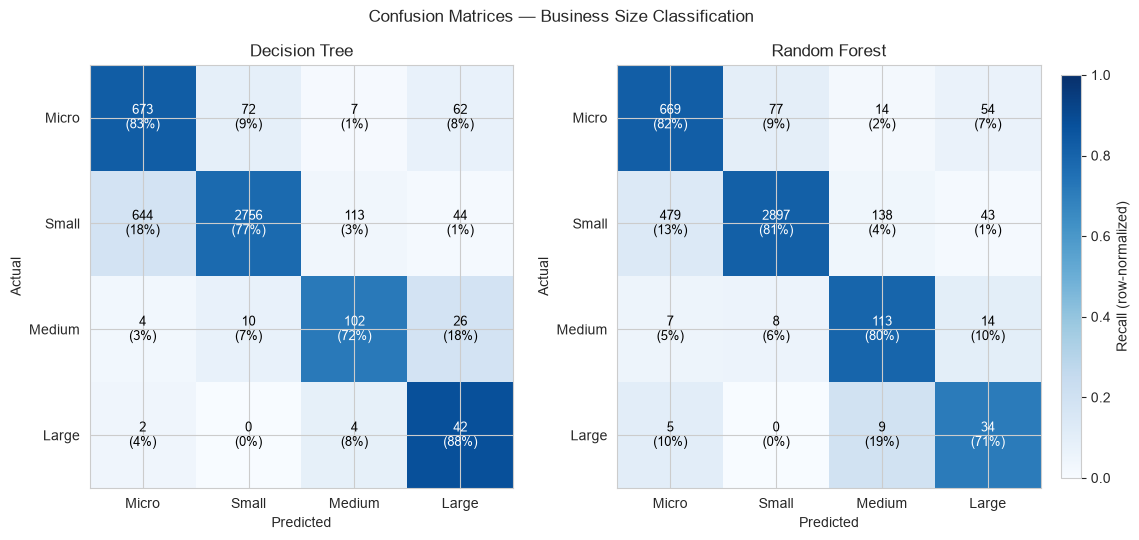

In [31]:
labels = ['Micro', 'Small', 'Medium', 'Large']

def plot_cm(ax, y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(len(labels))); ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels); ax.set_yticklabels(labels)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual'); ax.set_title(title)
    for i in range(len(labels)):
        for j in range(len(labels)):
            color = 'white' if cm_norm[i, j] > 0.5 else 'black'
            ax.text(j, i, f"{cm[i,j]}\n({cm_norm[i,j]*100:.0f}%)", ha='center', va='center', color=color, fontsize=9)
    return im

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
plot_cm(axes[0], y_test, dt_pred, "Decision Tree")
im = plot_cm(axes[1], y_test, rf_pred, "Random Forest")
fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02, label='Recall (row-normalized)')
plt.suptitle("Confusion Matrices — Business Size Classification")
plt.show()

### Feature Importance (Random Forest)

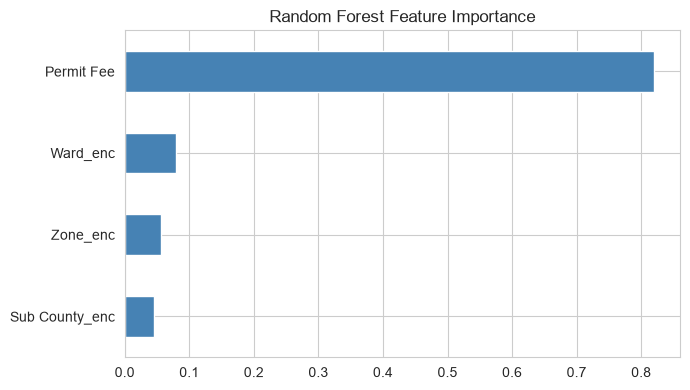

Permit Fee        0.819126
Ward_enc          0.078899
Zone_enc          0.056376
Sub County_enc    0.045599
dtype: float64

In [32]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7, 4))
importances.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title("Random Forest Feature Importance")
ax.invert_yaxis()
plt.tight_layout()
plt.show()
importances

## Summary

- Decision Tree and Random Forest were trained on location and licensing-fee
  attributes to classify businesses into four size categories.
- Random Forest outperformed the single Decision Tree on both accuracy and macro F1.
- Permit Fee was the strongest predictor, followed by Ward, Zone, and Sub County.
- The Large class remained the hardest to classify, consistent with its small
  sample size (191 records) identified during EDA.
- Activity/Category Code was deliberately excluded due to the label leakage
  identified in Section 3.6, so these results reflect genuine prediction from
  independent business attributes rather than a lookup of the classification rule.